In [17]:
### Will use AtlasOpenMagic package to download data and MC files and reconstruct Higgs peak
import numpy as np
import matplotlib.pyplot as plt
import uproot
import awkward as ak
import time
import atlasopenmagic as atom
import vector as v

In [3]:
#atom.available_releases()
atom.set_release("2025e-13tev-beta")
skim = '4lep'

#the data keys I copied from the tutorial
#TODO: separate out the backgrounds and figure out how to set the dids by self
data_keys = {
    r'Data':{'dids':['data']},
    r'Background $Z,t\bar{t},t\bar{t}+V,VVV$':{'dids': [410470,410155,410218,
                                                        410219,412043,364243,
                                                        364242,364246,364248,
                                                        700320,700321,700322,
                                                        700323,700324,700325], 'color': "#6b59d3" }, # purple
    r'Background $ZZ^{*}$':     {'dids': [700600],'color': "#ff0000" },# red
    r'Signal ($m_H$ = 125 GeV)':  {'dids': [345060, 346228, 346310, 346311, 346312,
                                          346340, 346341, 346342],'color': "#00cdff" },# light blue
}

allsamples = atom.build_dataset(data_keys, skim = skim,protocol = 'https', cache = True)

Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████| 374/374 [00:00<00:00, 552.04datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


In [22]:
# write functions for making cuts
variables = ['num_events','lep_pt','lep_eta','lep_phi','lep_e','lep_n','lep_charge','lep_type',
             'trigE','trigM','lep_isTrigMatched','lep_isLooseID','lep_isMediumID','lep_isLooseIso']

# cut on num leptons
# if true, keep event
def cut_lep_n(lep_n):
    cutboolarray = (lep_n == 4)
    return cutboolarray

# check if the event was triggered on either mass or energy
# if the event passes cut, return true
def cut_trigger(trigE,trigM):
    cutboolarray = trigE | trigM
    return (cutboolarray)

# trigmatch is awk array, each entry corresponds to an event
# each entry is a list of booleans for each lepton and whether it was triggered on
# ensure that at least one of the leptons in the event was triggered on
# returns a bool array, true if the event passes cut
# the ak.sum(axis=1) means we sum the boolean values in each event (sum columns/lepton bool values of each event row)
def cut_trigger_match(trigmatch):
    cutboolarray = (ak.sum(trigmatch,axis=1) >= 1) #1 is True, 0 is False
    return cutboolarray

# now check to make sure that every lepton in the event is isolated + identified
# if electron, check identified as electron and isolated, same with muon
# note that lep num cut must already be applied
def cut_ID_iso(pid,id_e,iso_e,id_mu,iso_mu):
    #if all 4 leptons are electron, identified, isolated, return True
    # also return True if we have 2mu, 2e
    # do this by 
    cut_earray = ak.sum((id_e & (pid == 11) & iso_e),axis=1) 
    cut_muarray = ak.sum((id_mu & (pid == 13) & iso_mu),axis=1)

    boolarray_4e_or4mu = (cut_earray | cut_muarray) == 4
    boolarray_2e       = (cut_earray == 2) 
    boolarray_2mu      = (cut_muarray ==2)

    # if event passes either muon or electron cut, return True
    return (boolarray_4e_or4mu | (boolarray_2e & boolarray_2mu))

# cut on pT
# these cuts can later be varied
# requirements: 1st particle pt > 20gev, 2nd > 15Gev, 3rd > 10GeV
def cut_pt(lep_pt):
    pt1 = lep_pt[:,0]
    pt2 = lep_pt[:,1]
    pt3 = lep_pt[:,2]
    pt1cut = pt1 > 20 # GeV
    pt2cut = pt2 > 15 
    pt3cut = pt3 > 10
    return (pt1cut & pt2cut & pt3cut)

# now cut on lep charge
# H->4l process must produce two pairs of oppositely charged leps, total charge = 0
# if true, event passes
def cut_lep_charge(lep_charge):
    cutboolarray = (ak.sum(lep_charge,axis = 1) == 0)
    return cutboolarray

# ensure that the event returned either 4mu, 4e, or 2mu+2e
#TODO upgrade the cut to ensure that the pair actually came from a Z decay
def cut_lep_type(lep_type):
    #each entry of lep_type is an array of the pids of the leptons inside
    pidsum = ak.sum(lep_type,axis=1)
    is4e = pidsum == 11*4
    is4mu = pidsum == 13*4
    is2e2mu = pidsum == 11*2+13*2
    cutboolarray = is4e | is4mu | is2e2mu
    return cutboolarray

def calc_mass(pt,eta,phi,E):
    # first create a 4vec for each of the particles
    p4 = v.zip({"pt":pt,"eta":eta,"phi":phi,"E":E})
    p4_sum = p4[:,0] + p4[:,1] + p4[:,2] + p4[:,3]
    M = p4_sum.M
    return M

In [23]:
# now examine one data file to ensure cuts are working properly
print("First data sample: " + str(allsamples['Data']['list'][0]))
# open the file, the tree is named analysis
file1 = uproot.open(allsamples['Data']['list'][0])
tree1 = file1['analysis']

# loop over iterated tree, check to see what the distribution of lep num is
lepnumarray =[]

for data in tree1.iterate(variables,library='ak'):
    for lepnum in data['lep_n']:
    # use to make a quick histo of the lepnum
        lepnumarray.append(lepnum)

    # do cuts on the data file
    print("Num events before cuts: "+str(len(data)))

    # the cuts are vectorized for effiency
    # each cut passes a bool array back to the data ak array
    # for all events with False in the bool array, the event is tossed

    data = data[cut_lep_n(data['lep_n'])]
    print("Num events after lep_n cuts: "+str(len(data)))

    data = data[cut_trigger(data['trigE'],data['trigM'])]
    data = data[cut_trigger_match(data['lep_isTrigMatched'])]
    print("Num events after trigger cuts: "+str(len(data)))

    # use histo the lep pid sums to check cut_lep_type function
    pidsum_aftrigcut = ak.sum(data['lep_type'],axis=1) 

    data = data[cut_pt(data['lep_pt'])]
    print("Num events after pt cuts: "+str(len(data)))

    # use histo the lep pid sums to check cut_lep_type function
    pidsum_afptcut = ak.sum(data['lep_type'],axis=1) 

    # electron should have loose ID, ID comes from ecal
    # muon should have medium ID (atlas recommendation?)
    # both should have loose iso criteria
    # inputs are pid,id_e,iso_e,id_mu,iso_mu
    data = data[cut_ID_iso(data['lep_type'],data['lep_isLooseID'],
                data['lep_isLooseIso'],data['lep_isMediumID'],
                data['lep_isLooseIso'])]
    print("Num events after ID iso cuts: "+str(len(data)))

    data = data[cut_lep_charge(data['lep_charge'])]
    print("Num events after lep charge cuts: "+str(len(data)))
    
    data = data[cut_lep_type(data['lep_type'])]
    print("Num events after lep type cuts: "+str(len(data)))

    # use histo the lep pid sums to check cut_lep_type function
    pidsum_aftypecut = ak.sum(data['lep_type'],axis=1) 

    #calculate mass
    data['mass'] = calc_mass(data['lep_pt'],data['lep_eta'],data['lep_phi'],data['lep_e'])
    print(data['mass'])


First data sample: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodD.4lep.root
Num events before cuts: 3708
Num events after lep_n cuts: 3424
Num events after trigger cuts: 395
Num events after pt cuts: 110
Num events after ID iso cuts: 2
Num events after lep charge cuts: 2
Num events after lep type cuts: 2
[472, 264]


In [131]:
#hist agrees with results of cut_lep_n
#plt.hist(lepnumarray,bins=np.arange(4,10,1))
#plt.xlim(4,8)

In [130]:
# hist agrees with 
#print(pidsum_b4typecut)
#plt.hist(pidsum_aftrigcut,bins=np.arange(0,100,1),color='red',label='after trig cuts')
#plt.hist(pidsum_afptcut,bins=np.arange(40,60,1),color='blue',label='after pt cuts')
#plt.hist(pidsum_aftypecut,bins=np.arange(0,100,1),color='green',label='after type cuts')
#plt.xlim(44,60)
#plt.legend()

In [ ]:
# now work on handling MC files
# first need a function for calculating the weights
# the total weight is given by lumi * cross section * (many other variables) / sum of weights
weight_vars = ["filteff", "kfac", "xsec", "mcWeight","ScaleFactor_PILEUP",
                "ScaleFactor_ELSE","ScaleFactor_MUON","ScaleFactor_LepTRIGGER"]

def calc_weight(weight_variables,tot_weight,lumi):
    # xsec given in pb, so multiply by 1000 to get in fb
    weight = lumi * 1000 / tot_weight
    for var in weight_variables:
        weight = weight * var


In [31]:
# loop through all files
lumi = 36.6 #fb-1, total luminosity of the release
allmass = {} # empty dictionary for ak arrays

# loop over Data, MC signal, MC backgrounds
for s in allsamples:
    print(s)
    if s != 'Data':
        break
    thissample_mass = []
    # loop over all files in this sample
    for i,f in enumerate(allsamples[s]['list']):
        #if i>5:
        #    break
        thisfile_mass = []
        starttime = time.time() # start timer
        print(r'Processing file: ' + str(f))

        # open the file, the tree is named analysis
        file = uproot.open(f)
        tree = file['analysis']
        # loop through tree
        for data in tree.iterate(variables,library='ak'):
            nIn = len(data)
            # do cuts on the data file
            print("Num events before cuts: "+str(len(data)))

            # the cuts are vectorized for effiency
            # each cut passes a bool array back to the data ak array
            # for all events with False in the bool array, the event is tossed

            data = data[cut_lep_n(data['lep_n'])]
            print("Num events after lep_n cuts: "+str(len(data)))

            data = data[cut_trigger(data['trigE'],data['trigM'])]
            data = data[cut_trigger_match(data['lep_isTrigMatched'])]
            print("Num events after trigger cuts: "+str(len(data)))

            data = data[cut_pt(data['lep_pt'])]
            print("Num events after pt cuts: "+str(len(data)))

            # electron should have loose ID, ID comes from ecal
            # muon should have medium ID (atlas recommendation?)
            # both should have loose iso criteria
            # inputs are pid,id_e,iso_e,id_mu,iso_mu
            data = data[cut_ID_iso(data['lep_type'],data['lep_isLooseID'],
                        data['lep_isLooseIso'],data['lep_isMediumID'],
                        data['lep_isLooseIso'])]
            print("Num events after ID iso cuts: "+str(len(data)))

            data = data[cut_lep_charge(data['lep_charge'])]
            print("Num events after lep charge cuts: "+str(len(data)))
            
            data = data[cut_lep_type(data['lep_type'])]
            print("Num events after lep type cuts: "+str(len(data)))

            nOut = len(data)

            #calculate mass
            data['mass'] = calc_mass(data['lep_pt'],data['lep_eta'],data['lep_phi'],data['lep_e'])
            #print(data['mass'])
            thisfile_mass.append(data['mass'])

        thissample_mass.append(ak.concatenate(thisfile_mass))
        endtime = time.time()
        duration = endtime - starttime
        print(f"\t nIn:{nIn}\tnOut:{nOut}\tin {duration} s.")

    allmass[s] = ak.concatenate(thissample_mass)





Data
Processing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodD.4lep.root
Num events before cuts: 3708
Num events after lep_n cuts: 3424
Num events after trigger cuts: 395
Num events after pt cuts: 110
Num events after ID iso cuts: 2
Num events after lep charge cuts: 2
Num events after lep type cuts: 2
	 nIn:3708	nOut:2	in 0.18227815628051758 s.
Processing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodE.4lep.root
Num events before cuts: 27501
Num events after lep_n cuts: 25092
Num events after trigger cuts: 3420
Num events after pt cuts: 765
Num events after ID iso cuts: 19
Num events after lep charge cuts: 17
Num events after lep type cuts: 17
	 nIn:27501	nOut:17	in 0.600844144821167 s.
Processing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodF.4lep.root
Num events before cuts: 17783
Num ev

Num of data events that pass cut: 1279
68 68


<ErrorbarContainer object of 3 artists>

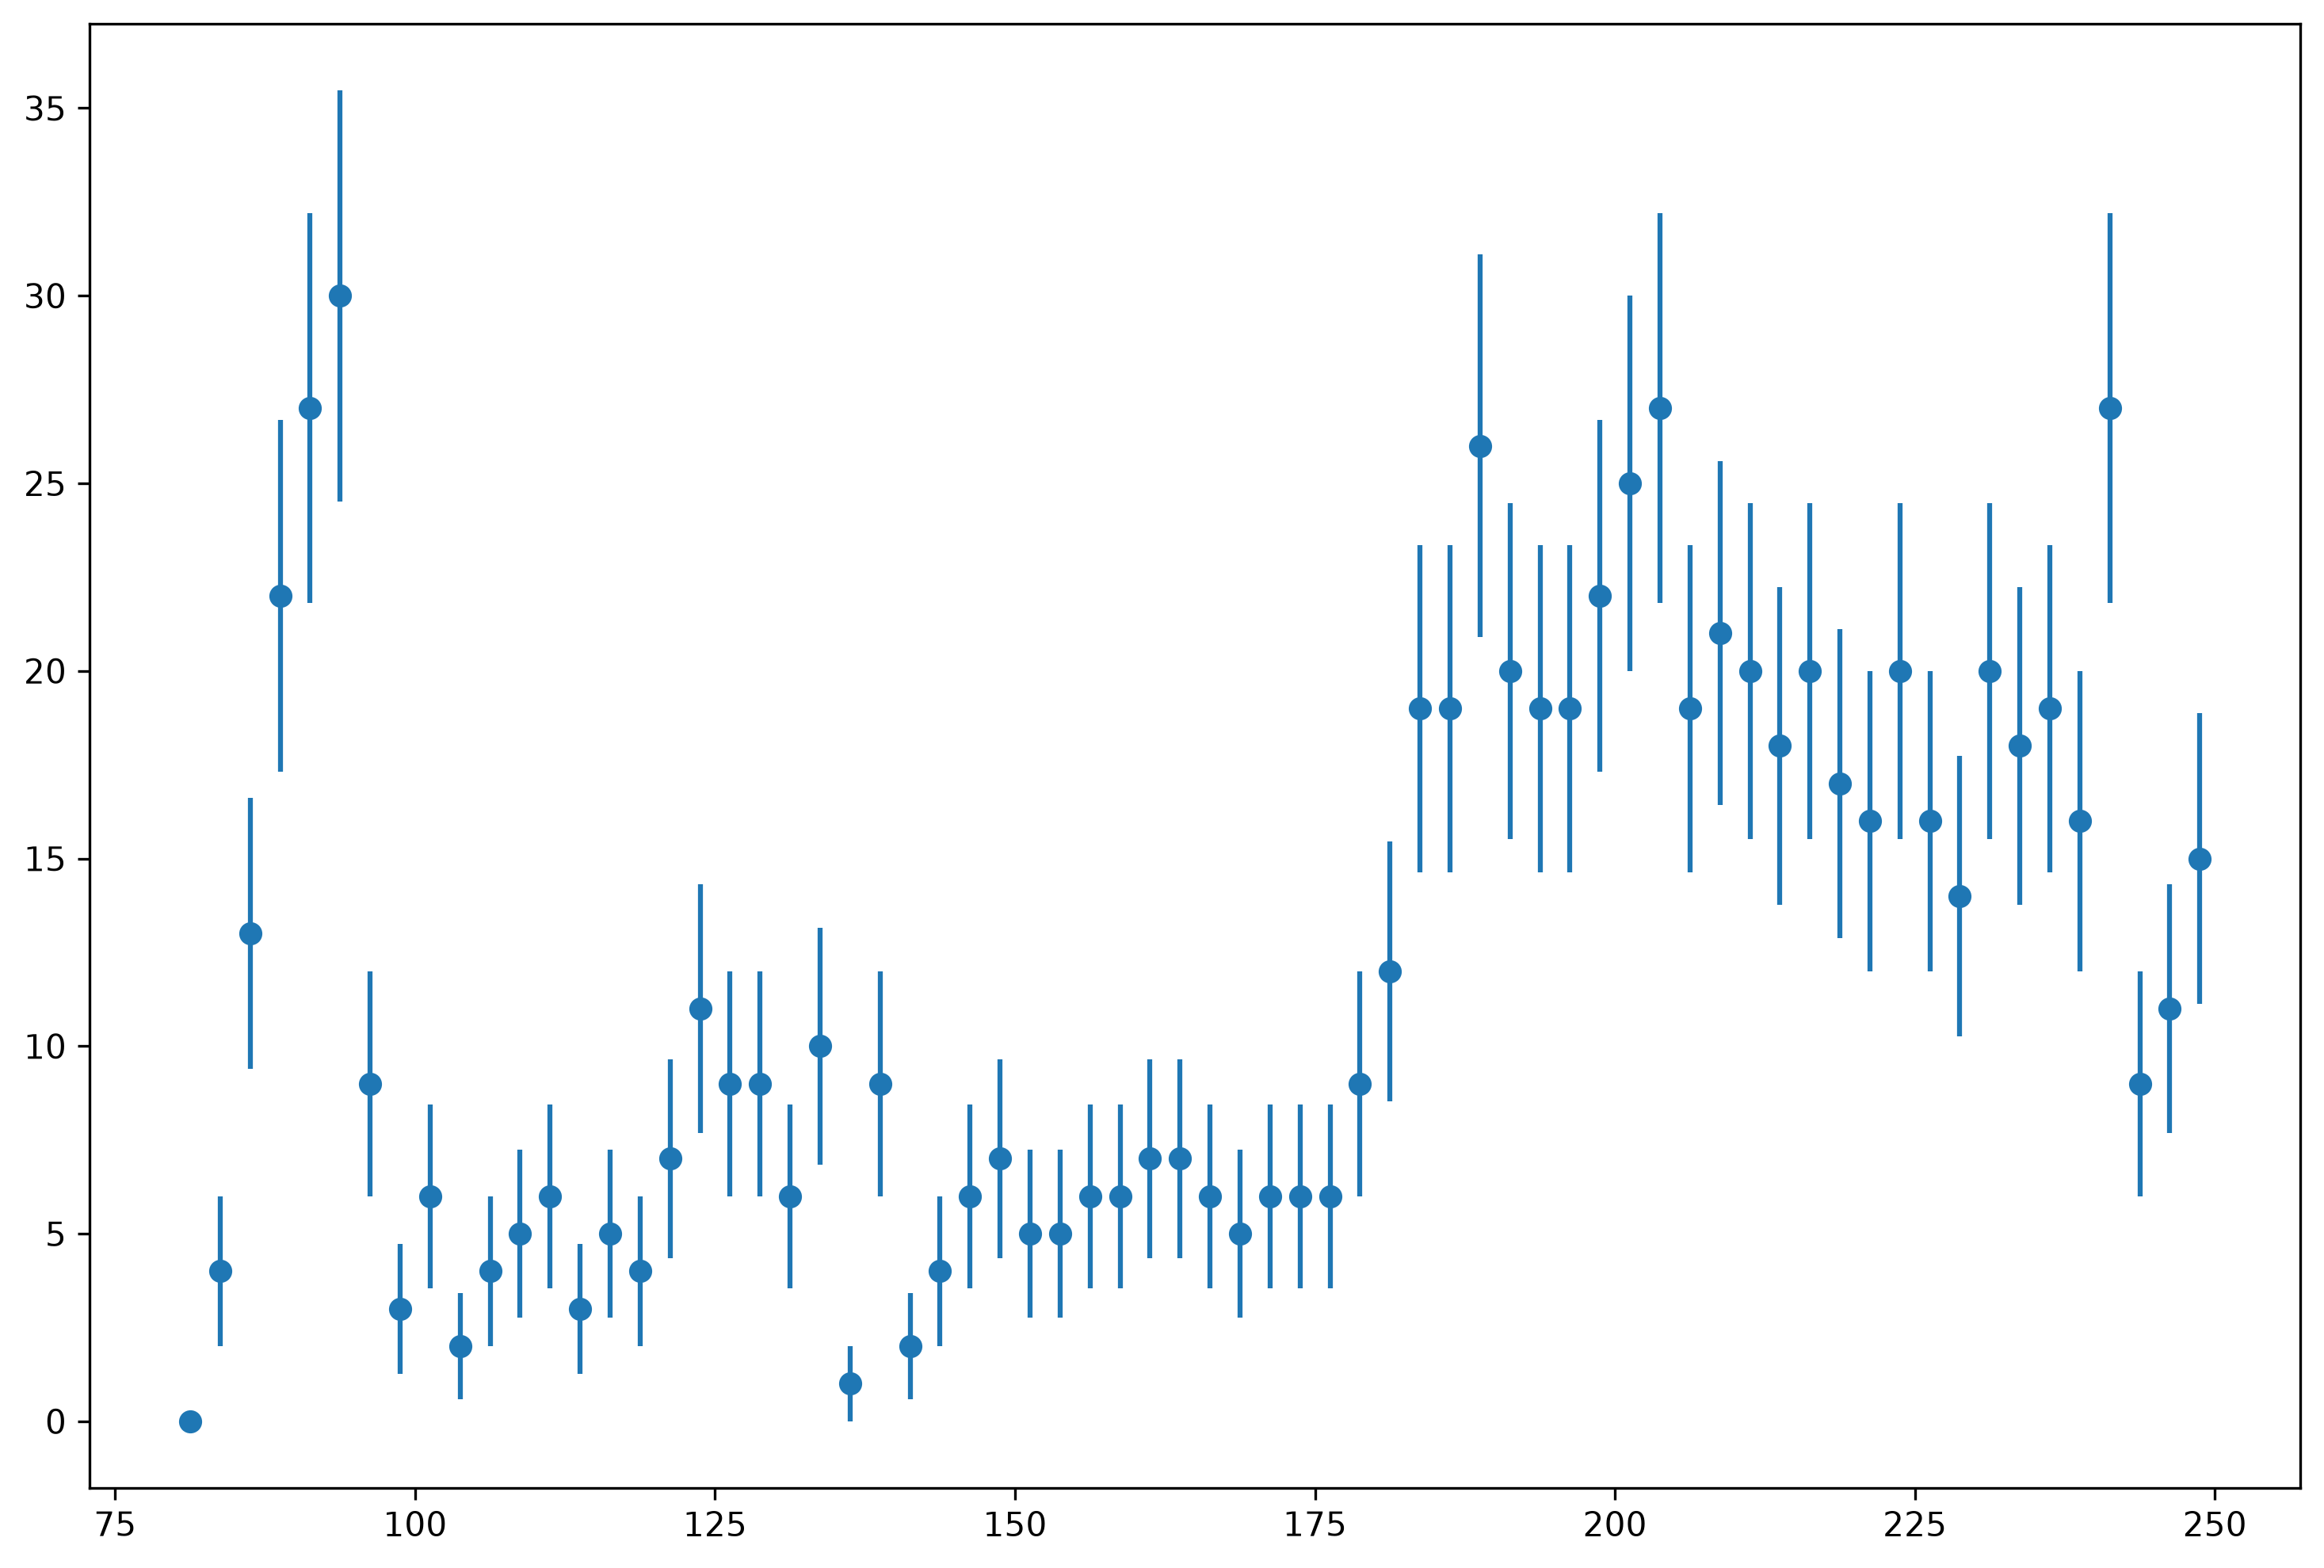

In [42]:
# Make plots -> start with just data

# plot variables
#TODO - change the plot dynamics
xmin = 80 # GeV for all 
xmax = 250
stepsize = 2.5 
binlist = np.arange(xmin,xmax+stepsize,stepsize)
bincenters = np.arange(xmin+stepsize/2,xmax+stepsize/2,stepsize)


data_x = ak.to_numpy(allmass['Data'])
print(f'Num of data events that pass cut: {len(data_x)}')
data_y,_ = np.histogram(data_x,bins=binlist)
data_y_err = np.sqrt(data_y) # statistical error use poisson uncertainty

print(len(bincenters),len(data_y))

fig, ax = plt.subplots(figsize=(12,8),dpi=300)
ax.errorbar(bincenters,data_y,yerr=data_y_err,fmt='o')


Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████| 374/374 [00:03<00:00, 93.98datasets/s]
✓ Successfully cached 374 datasets.
Metadata updated with local paths for 1 samples (['data']) and 1 files (out of 16 in those samples).


AttributeError: module 'atlasopenmagic' has no attribute 'local_path'